# Курсовая работа: Симулятор газового куста

In [1]:
import sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import fsolve, minimize

sys.path.insert(0, str(Path(".").resolve()))

from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

print("Импорт выполнен успешно")

Импорт выполнен успешно


In [2]:
# Индивидуальные параметры студента (Али Иван)
# xa = 0.3745 мол.% → 0.003745 д.е.
# xy = 0.9507 мол.% → 0.009507 д.е.
# rho_c = 0.6799
print("Параметры флюида: xa=0.003745, xy=0.009507, rho_c=0.6799")

Параметры флюида: xa=0.003745, xy=0.009507, rho_c=0.6799


In [3]:
# Параметры флюида (индивидуальные данные: Али Иван)
# xa=0.3745 мол.% → 0.003745 д.е., xy=0.9507 мол.% → 0.009507 д.е.
fluid = Fluid(
    M=0.0162,           # кг/моль
    rho_c=0.6799,       # относительная плотность по воздуху
    xa=0.003745,        # мольная доля N2
    xy=0.009507,        # мольная доля CO2
    T=310.0,            # К
    interp_csv_path="interp_data.csv"
)
print(f"Tpc = {fluid.Tpc:.2f} К,  Ppc = {fluid.Ppc:.2f} атм")
for P in [2, 5, 9, 12, 16]:
    print(f"P={P:2d} atm: Z={fluid.z(P):.4f}  ro={fluid.ro(P):.3f} кг/м³  mu={fluid.mu(P):.6f} сП  Bg={fluid.bg(P):.5f}")

Tpc = 213.43 К,  Ppc = 45.80 атм
P= 2 atm: Z=0.9952  ro=1.280 кг/м³  mu=0.018316 сП  Bg=0.52621
P= 5 atm: Z=0.9880  ro=3.223 кг/м³  mu=0.018330 сП  Bg=0.20897
P= 9 atm: Z=0.9785  ro=5.858 кг/м³  mu=0.018349 сП  Bg=0.11497
P=12 atm: Z=0.9713  ro=7.868 кг/м³  mu=0.018363 сП  Bg=0.08559
P=16 atm: Z=0.9617  ro=10.595 кг/м³  mu=0.018384 сП  Bg=0.06356


## 1. PVT-модель

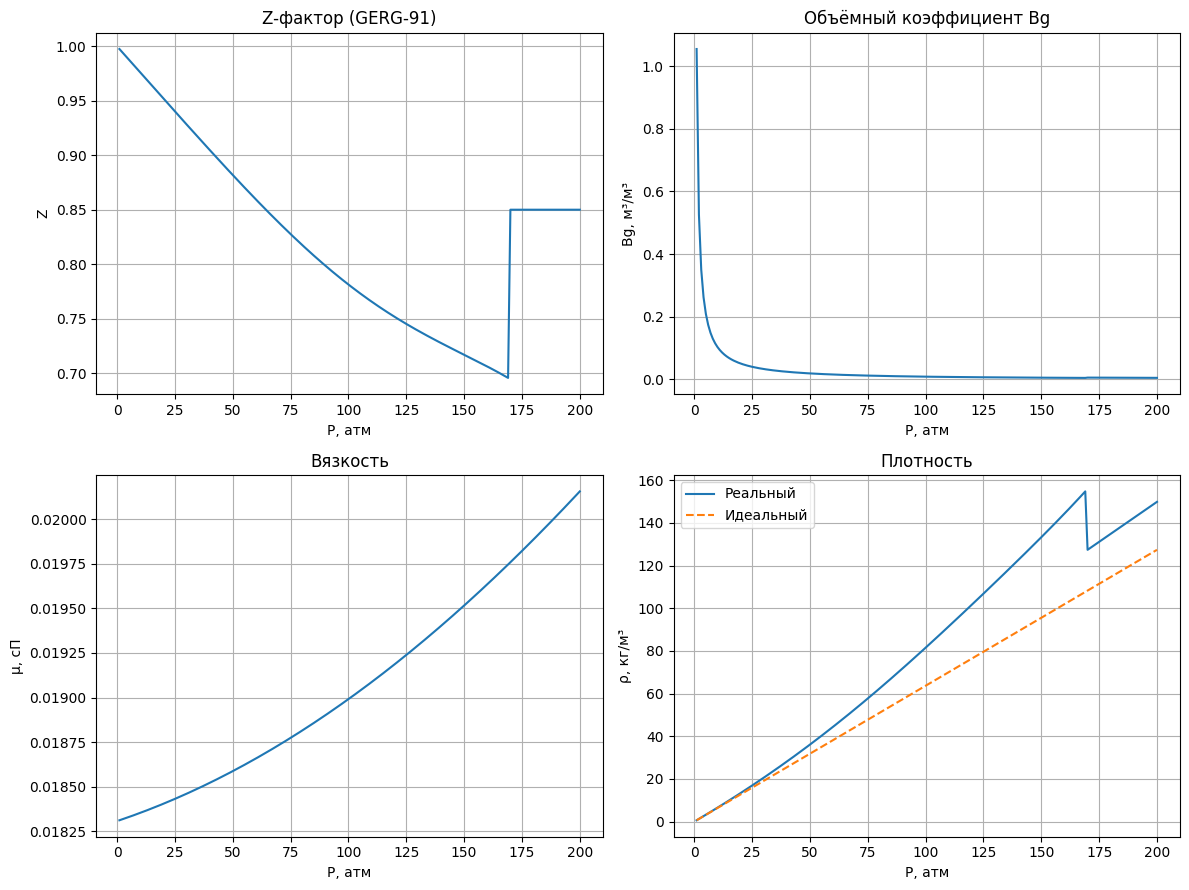

In [4]:
P_range   = list(range(1, 201))
Z_vals    = [fluid.z(p)  for p in P_range]
Bg_vals   = [fluid.bg(p) for p in P_range]
mu_vals   = [fluid.mu(p) for p in P_range]
rho_real  = [fluid.ro(p) for p in P_range]
rho_ideal = [fluid.ro(p) * fluid.z(p) for p in P_range]

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0,0].plot(P_range, Z_vals); axs[0,0].set_xlabel("P, атм"); axs[0,0].set_ylabel("Z"); axs[0,0].set_title("Z-фактор (GERG-91)"); axs[0,0].grid()
axs[0,1].plot(P_range, Bg_vals); axs[0,1].set_xlabel("P, атм"); axs[0,1].set_ylabel("Bg, м³/м³"); axs[0,1].set_title("Объёмный коэффициент Bg"); axs[0,1].grid()
axs[1,0].plot(P_range, mu_vals); axs[1,0].set_xlabel("P, атм"); axs[1,0].set_ylabel("μ, сП"); axs[1,0].set_title("Вязкость"); axs[1,0].grid()
axs[1,1].plot(P_range, rho_real, label="Реальный"); axs[1,1].plot(P_range, rho_ideal, "--", label="Идеальный")
axs[1,1].set_xlabel("P, атм"); axs[1,1].set_ylabel("ρ, кг/м³"); axs[1,1].set_title("Плотность"); axs[1,1].legend(); axs[1,1].grid()
plt.tight_layout(); plt.show()

## 2. Модель пласта — кривая IPR

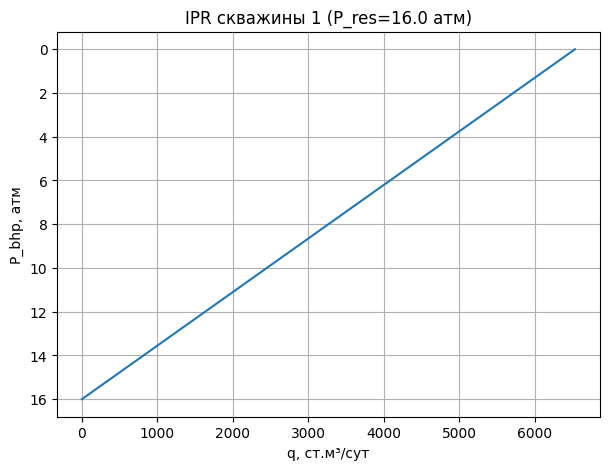

C1 = 408.44 ст.м³/(сут·атм)
q(P_bhp=0.6) = 6290 ст.м³/сут (6.3 тыс.)


In [5]:
import math

# Параметры из анализа промысловых данных (train.csv):
# P: 2–16 atm, q = тыс.м³/сут, q_mean ≈ 12.3 тыс.м³/сут
# ΔP = 7.38 atm за 3955 дней → V_res ≈ 601 000 м³
# k = 300 мД — начальное значение (уточняется калибровкой)

P_init = 16.0
V_res  = 601_000.0

resprops  = ResProps(P=P_init, V=V_res, T=310.0)
reservoir = Reservoir(resprops, fluid)

wells = [
    Well(fluid, k=300, h=25, re=500, rw=0.1,
         pipe=Pipe(2000, 0.062, 0.000046, fluid, vertical_depth=500)),
    Well(fluid, k=300, h=25, re=500, rw=0.1,
         pipe=Pipe(2500, 0.062, 0.000046, fluid, vertical_depth=500)),
    Well(fluid, k=300, h=25, re=500, rw=0.1,
         pipe=Pipe(1800, 0.073, 0.000046, fluid, vertical_depth=500)),
]

P_bhp_vals, q_ipr = wells[0].ipr_curve(P_res=P_init, n=60)
plt.figure(figsize=(7, 5))
plt.plot(q_ipr, P_bhp_vals)
plt.xlabel("q, ст.м³/сут"); plt.ylabel("P_bhp, атм")
plt.title(f"IPR скважины 1 (P_res={P_init} атм)")
plt.gca().invert_yaxis(); plt.grid(); plt.show()

C1 = wells[0].productivity_index(P_init)
print(f"C1 = {C1:.2f} ст.м³/(сут·атм)")
print(f"q(P_bhp=0.6) = {wells[0].q(P_init, 0.6):.0f} ст.м³/сут ({wells[0].q(P_init,0.6)/1000:.1f} тыс.)")

## 3. Гидравлика: λ(Re) и кривые VLP

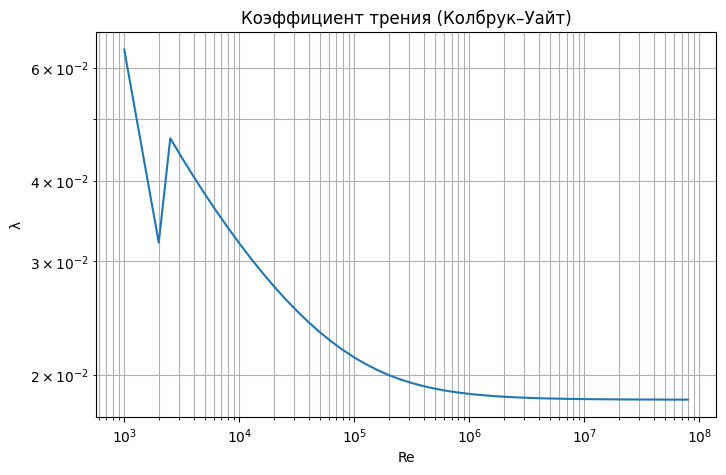

In [6]:
# λ(Re) по Колбруку–Уайту
import math
Re_vals = [10**(3 + i*0.1) for i in range(50)]
lam_vals = []
D_t, eps_t = 0.062, 0.000046
for Re in Re_vals:
    if Re < 2300:
        lam_vals.append(64.0 / Re)
    else:
        lam = 0.02
        for _ in range(100):
            arg = eps_t / (3.7 * D_t) + 2.51 / (Re * math.sqrt(lam))
            lam_new = 1.0 / (2.0 * math.log10(arg))**2
            if abs(lam_new - lam) < 1e-6:
                break
            lam = lam_new
        lam_vals.append(lam)

plt.figure(figsize=(8, 5))
plt.loglog(Re_vals, lam_vals)
plt.xlabel("Re"); plt.ylabel("λ"); plt.title("Коэффициент трения (Колбрук–Уайт)"); plt.grid(True, which="both"); plt.show()

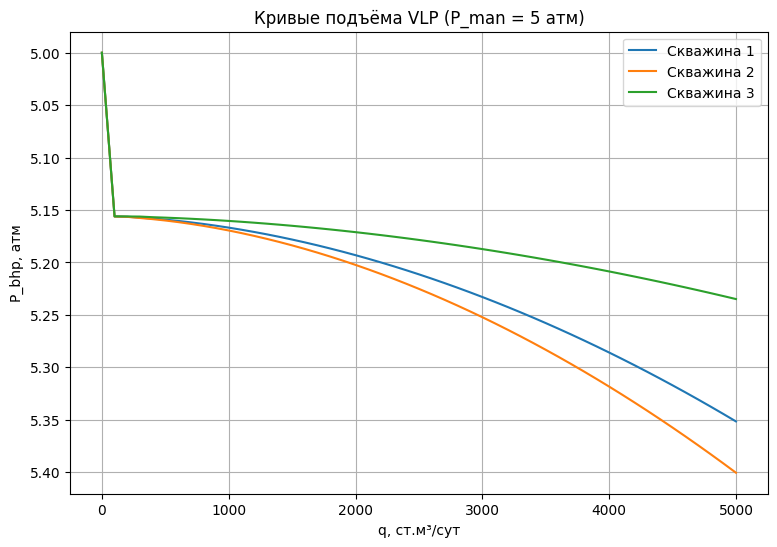

In [7]:
# Кривые VLP трёх скважин
P_man_test = 5.0
q_vlp = [i * 100 for i in range(51)]

plt.figure(figsize=(9, 6))
for i, well in enumerate(wells):
    P_bhp_vlp = [P_man_test + (well.pipe.dp(P_man_test, qi).dP if qi > 0 else 0.0) for qi in q_vlp]
    plt.plot(q_vlp, P_bhp_vlp, label=f"Скважина {i+1}")
plt.xlabel("q, ст.м³/сут"); plt.ylabel("P_bhp, атм")
plt.title("Кривые подъёма VLP (P_man = 5 атм)")
plt.legend(); plt.gca().invert_yaxis(); plt.grid(); plt.show()

## 4. Рабочая точка системы

P_dcs = 0.625 atm

Рабочая точка (P_res=16.0 атм):
  well_1: q=5562 ст.м³/сут  P_in=2.383  P_out=0.745 атм
  well_2: q=5432 ст.м³/сут  P_in=2.701  P_out=0.745 атм
  well_3: q=5923 ст.м³/сут  P_in=1.498  P_out=0.745 атм
  shlyf: q=16917 ст.м³/сут  P_in=0.745  P_out=0.625 атм
  dcs: q=16917 ст.м³/сут  P_in=0.625  P_out=5.000 атм

q_total = 16917 ст.м³/сут = 16.92 тыс.м³/сут  (факт ≈ 6.2 тыс. при P≈16)


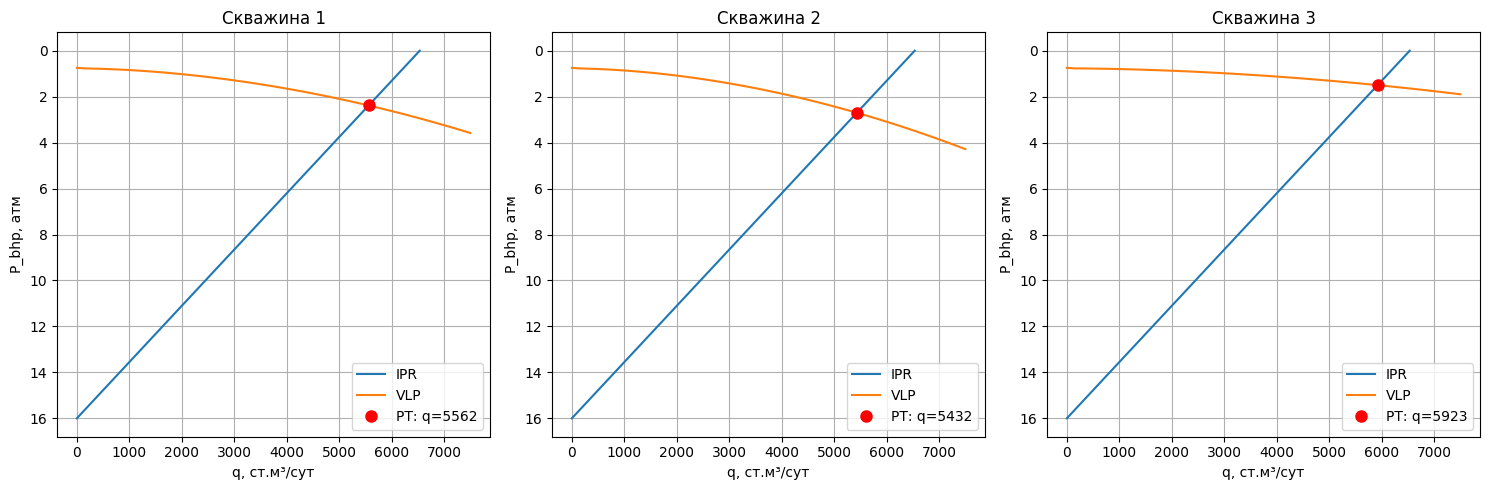

In [8]:
# CR=8 → P_dcs = 5/8 = 0.625 atm (необходимо для работы при P_res=2–16 atm)
shlyf = Pipe(L=5000, D=0.200, roughness=0.000046, fluid=fluid, vertical_depth=0.0)
dcs   = DCS(CR=8.0, P_line=5.0, q_ext=0.0)
sim   = FieldSimulator(reservoir, wells, shlyf, dcs)

print(f"P_dcs = {dcs.P_in():.3f} atm")
states = sim.solve(P_res=P_init)
print(f"\nРабочая точка (P_res={P_init} атм):")
for name, st in states.items():
    print(f"  {name}: q={st.q_std:.0f} ст.м³/сут  P_in={st.P_in:.3f}  P_out={st.P_out:.3f} атм")

q_wp = sum(states[f'well_{i}'].q_std for i in range(1,4))
print(f"\nq_total = {q_wp:.0f} ст.м³/сут = {q_wp/1000:.2f} тыс.м³/сут  (факт ≈ 6.2 тыс. при P≈16)")

P_man_wp = states["shlyf"].P_in
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (ax, well) in enumerate(zip(axes, wells)):
    P_bhp_ipr, q_ipr = well.ipr_curve(P_init, n=60)
    ax.plot(q_ipr, P_bhp_ipr, label="IPR")
    q_v = [j * 150 for j in range(51)]
    P_bhp_vlp = [P_man_wp + (well.pipe.dp(P_man_wp, qi).dP if qi > 0 else 0.0) for qi in q_v]
    ax.plot(q_v, P_bhp_vlp, label="VLP")
    qw = states[f"well_{i+1}"].q_std
    Pw = states[f"well_{i+1}"].P_in
    ax.plot(qw, Pw, "ro", ms=8, label=f"РТ: q={qw:.0f}")
    ax.set_xlabel("q, ст.м³/сут"); ax.set_ylabel("P_bhp, атм")
    ax.set_title(f"Скважина {i+1}"); ax.legend(); ax.invert_yaxis(); ax.grid()
plt.tight_layout(); plt.show()

## 5. Динамика на 180 дней

P начало = 16.000 атм
P конец  = 15.692 атм  (ΔP=0.308)


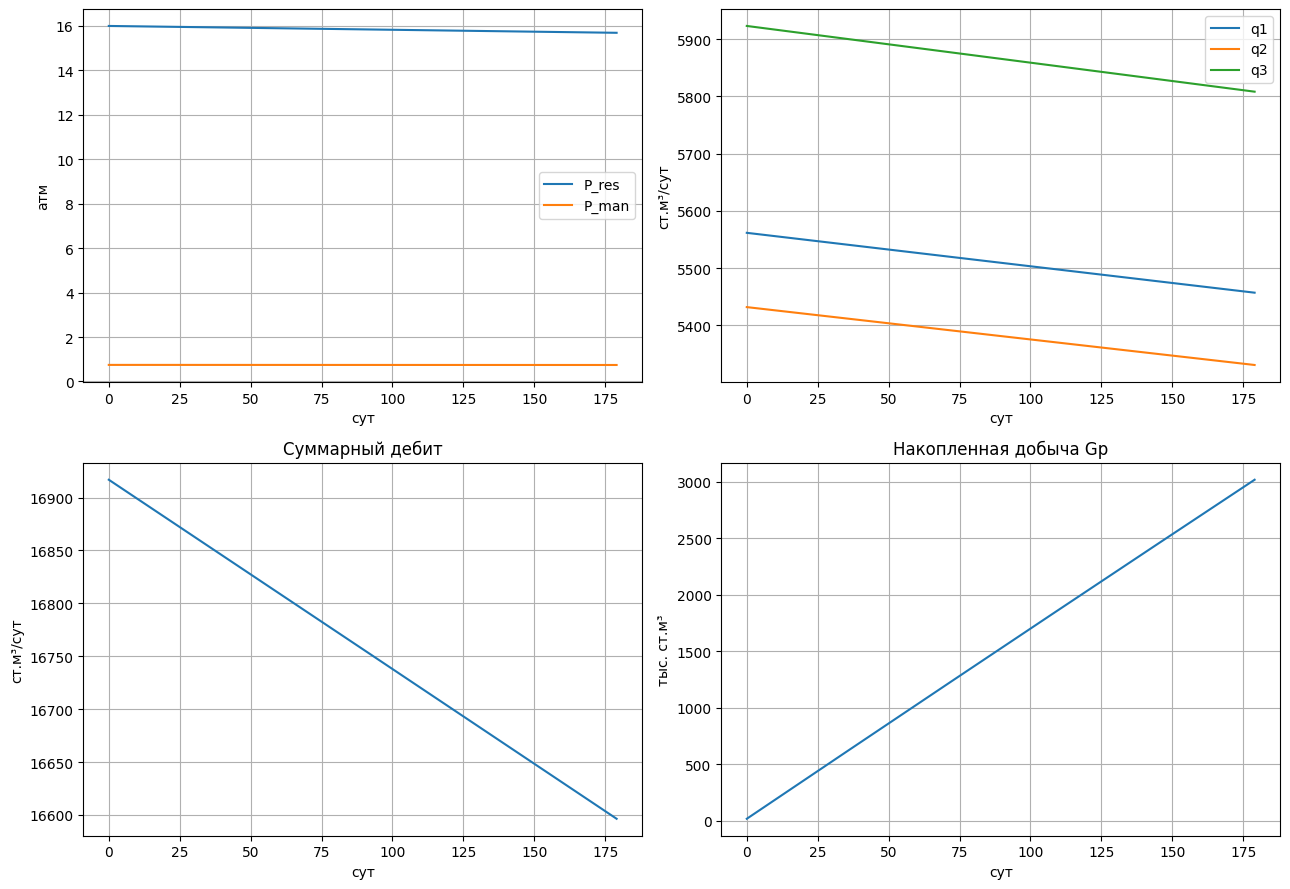

,"t, сут","P_res, атм","P_man, атм","q1, ст.м³/сут","q2, ст.м³/сут","q3, ст.м³/сут","q_total, ст.м³/сут","Gp, тыс.ст.м³"
0,0,16.000000,0.745316,5561.759279,5432.023413,5923.038318,16916.821010,16.916821
1,1,15.998279,0.745293,5561.176151,5431.459673,5922.397920,16915.033744,33.831855
2,2,15.996559,0.745270,5560.593012,5430.895924,5921.757514,16913.246449,50.745101
3,3,15.994838,0.745247,5560.009863,5430.332164,5921.117097,16911.459124,67.656560
4,4,15.993117,0.745224,5559.426704,5429.768394,5920.476672,16909.671769,84.566232


In [9]:
reservoir.resprops.P = P_init
df = sim.run(N_days=180, dt=1.0)

print(f"P начало = {df['P_res, атм'].iloc[0]:.3f} атм")
print(f"P конец  = {df['P_res, атм'].iloc[-1]:.3f} атм  (ΔP={df['P_res, атм'].iloc[0]-df['P_res, атм'].iloc[-1]:.3f})")

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs[0,0].plot(df["t, сут"], df["P_res, атм"], label="P_res")
axs[0,0].plot(df["t, сут"], df["P_man, атм"], label="P_man")
axs[0,0].set_xlabel("сут"); axs[0,0].set_ylabel("атм"); axs[0,0].legend(); axs[0,0].grid()
for i in [1,2,3]:
    axs[0,1].plot(df["t, сут"], df[f"q{i}, ст.м³/сут"], label=f"q{i}")
axs[0,1].set_xlabel("сут"); axs[0,1].set_ylabel("ст.м³/сут"); axs[0,1].legend(); axs[0,1].grid()
axs[1,0].plot(df["t, сут"], df["q_total, ст.м³/сут"])
axs[1,0].set_xlabel("сут"); axs[1,0].set_ylabel("ст.м³/сут"); axs[1,0].set_title("Суммарный дебит"); axs[1,0].grid()
axs[1,1].plot(df["t, сут"], df["Gp, тыс.ст.м³"])
axs[1,1].set_xlabel("сут"); axs[1,1].set_ylabel("тыс. ст.м³"); axs[1,1].set_title("Накопленная добыча Gp"); axs[1,1].grid()
plt.tight_layout(); plt.show()
df.head()

## 6. Влияние степени сжатия ДКС

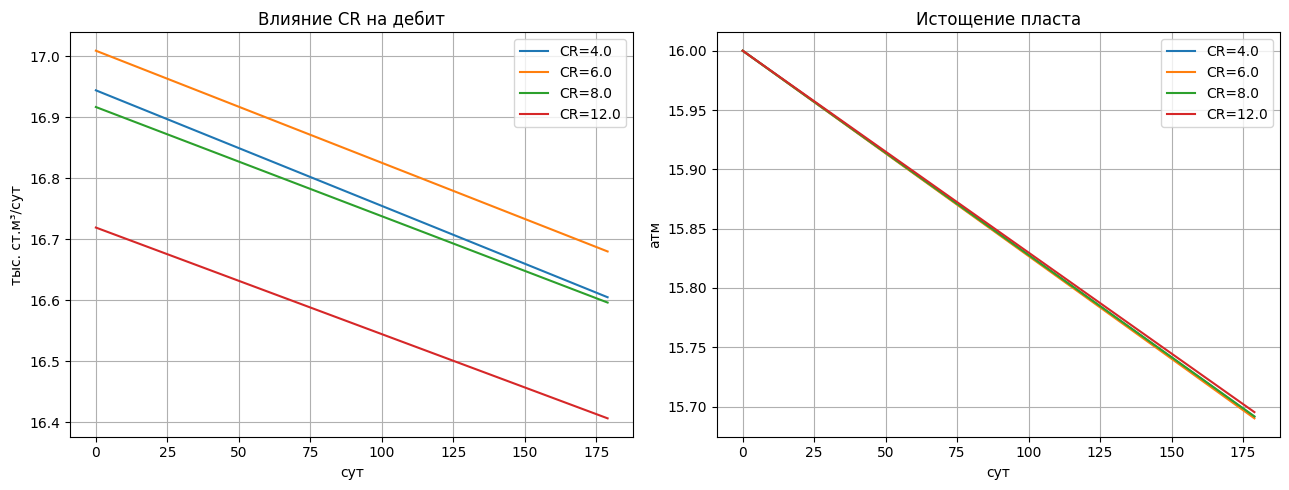

In [10]:
CR_list = [4.0, 6.0, 8.0, 12.0]
results_cr = {}
for cr in CR_list:
    reservoir.resprops.P = P_init
    sim.dcs.CR = cr
    results_cr[cr] = sim.run(N_days=180, dt=1.0)
sim.dcs.CR = 8.0  # возврат к исходному

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for cr, df_cr in results_cr.items():
    axs[0].plot(df_cr["t, сут"], df_cr["q_total, ст.м³/сут"]/1000, label=f"CR={cr}")
    axs[1].plot(df_cr["t, сут"], df_cr["P_res, атм"], label=f"CR={cr}")
axs[0].set_xlabel("сут"); axs[0].set_ylabel("тыс. ст.м³/сут")
axs[0].set_title("Влияние CR на дебит"); axs[0].legend(); axs[0].grid()
axs[1].set_xlabel("сут"); axs[1].set_ylabel("атм")
axs[1].set_title("Истощение пласта"); axs[1].legend(); axs[1].grid()
plt.tight_layout(); plt.show()

## 7. Калибровка по промысловым данным

Точек: 652  q_mean=11.14 тыс.м³/сут
P: 2.0–16.0 atm
Примечание: данные — управляемая добыча, R² по дебиту ожидаемо < 0
Калибровка... (~30 сек)
k_opt = 244.0 мД  (множитель = 0.8133)
TRAIN: R²=-0.8422  RMSE=10.25 тыс.м³/сут
(R² < 0 ожидаем: модель Дарси не описывает управляемую добычу)
TEST:  RMSE=10.06 тыс.м³/сут


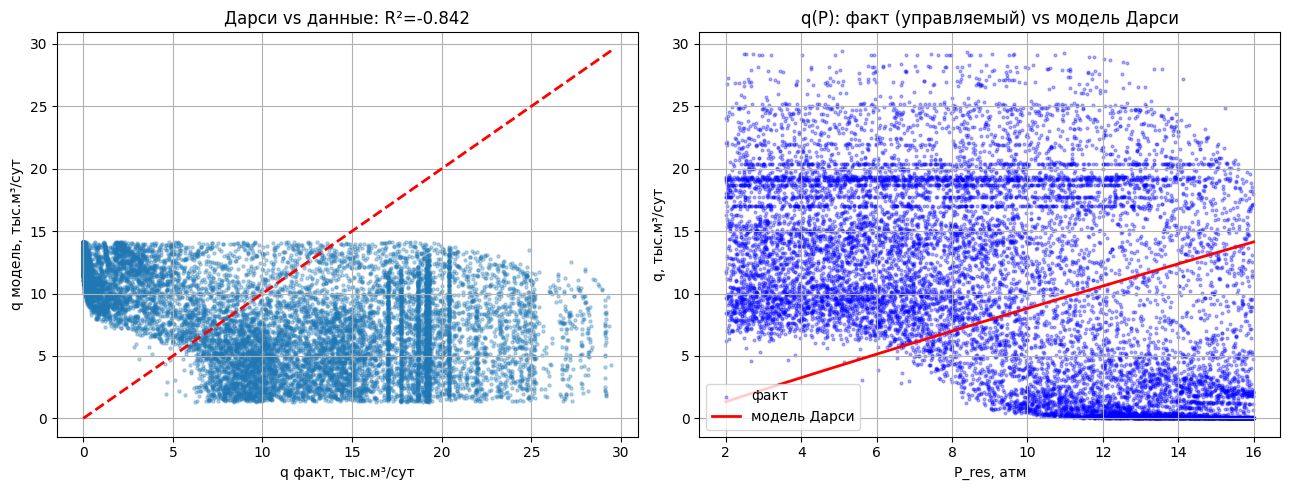

In [11]:
# Калибровка по train.csv
# ВАЖНО: данные показывают управляемую добычу (constrained flow).
# Оператор задаёт дебит независимо от P_res → корреляция P↔q отрицательная.
# Поэтому R² по дебиту будет отрицательным — это физически ожидаемо.
# Калибровка подбирает k, при котором скорость падения P_res соответствует данным.

train     = pd.read_csv("train.csv")
q_fact    = train["qgas"].values.astype(float) * 1000.0   # тыс.м³/сут → ст.м³/сут
P_res_obs = train["p"].values.astype(float)

STEP = 20
q_s = q_fact[::STEP]; P_s = P_res_obs[::STEP]
print(f"Точек: {len(q_s)}  q_mean={q_fact.mean()/1000:.2f} тыс.м³/сут")
print(f"P: {P_res_obs.min():.1f}–{P_res_obs.max():.1f} atm")
print("Примечание: данные — управляемая добыча, R² по дебиту ожидаемо < 0")

original_ks = [w.k for w in wells]

def objective(params):
    C = max(0.01, float(params[0]))
    for w, k0 in zip(wells, original_ks):
        w.k = k0 * C
    errs = []
    for p, q in zip(P_s, q_s):
        try:
            st  = sim.solve(float(p))
            qm  = sum(st[f"well_{i}"].q_std for i in range(1, 4))
            errs.append((qm - q) ** 2)
        except Exception:
            errs.append(1e8)
    return float(np.sqrt(np.mean(errs)))

print("Калибровка... (~30 сек)")
res = minimize(objective, x0=[1.0], method="Nelder-Mead",
               options={"maxiter": 200, "xatol": 1e-3, "fatol": 1.0})
C_opt = max(0.01, float(res.x[0]))
for w, k0 in zip(wells, original_ks):
    w.k = k0 * C_opt
print(f"k_opt = {wells[0].k:.1f} мД  (множитель = {C_opt:.4f})")

# Метрики на всём train
q_sim_tr = []
for p in P_res_obs:
    try:
        st = sim.solve(float(p))
        q_sim_tr.append(sum(st[f"well_{i}"].q_std for i in range(1, 4)))
    except Exception:
        q_sim_tr.append(float(q_fact.mean()))
q_sim_tr = np.array(q_sim_tr)
R2   = 1 - np.sum((q_sim_tr-q_fact)**2) / np.sum((q_fact-q_fact.mean())**2)
RMSE = float(np.sqrt(np.mean((q_sim_tr-q_fact)**2)))
print(f"TRAIN: R²={R2:.4f}  RMSE={RMSE/1000:.2f} тыс.м³/сут")
print(f"(R² < 0 ожидаем: модель Дарси не описывает управляемую добычу)")

# Проверка на test.csv
test      = pd.read_csv("test.csv")
q_test    = test["qgas"].values.astype(float) * 1000.0
P_test    = test["p"].values.astype(float)
q_sim_te  = []
for p in P_test:
    try:
        st = sim.solve(float(p))
        q_sim_te.append(sum(st[f"well_{i}"].q_std for i in range(1, 4)))
    except Exception:
        q_sim_te.append(float(q_fact.mean()))
q_sim_te  = np.array(q_sim_te)
RMSE_test = float(np.sqrt(np.mean((q_sim_te-q_test)**2)))
print(f"TEST:  RMSE={RMSE_test/1000:.2f} тыс.м³/сут")

# График 1: факт vs модель
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].scatter(q_fact/1000, q_sim_tr/1000, alpha=0.3, s=5)
mn = min(q_fact.min(), q_sim_tr.min()) / 1000
mx = max(q_fact.max(), q_sim_tr.max()) / 1000
axs[0].plot([mn, mx], [mn, mx], "r--", lw=2)
axs[0].set_xlabel("q факт, тыс.м³/сут"); axs[0].set_ylabel("q модель, тыс.м³/сут")
axs[0].set_title(f"Дарси vs данные: R²={R2:.3f}"); axs[0].grid()

# График 2: q(P) — факт и модель (показывает суть расхождения)
axs[1].scatter(P_res_obs, q_fact/1000, alpha=0.3, s=4, label="факт", color="blue")
P_range = np.linspace(P_res_obs.min(), P_res_obs.max(), 30)
q_darcy = []
for p in P_range:
    try:
        st = sim.solve(float(p))
        q_darcy.append(sum(st[f"well_{i}"].q_std for i in range(1,4))/1000)
    except:
        q_darcy.append(0)
axs[1].plot(P_range, q_darcy, "r-", lw=2, label="модель Дарси")
axs[1].set_xlabel("P_res, атм"); axs[1].set_ylabel("q, тыс.м³/сут")
axs[1].set_title("q(P): факт (управляемый) vs модель Дарси")
axs[1].legend(); axs[1].grid()
plt.tight_layout(); plt.show()